In [2]:
import os
print('Jupyter working directory:', os.getcwd())

Jupyter working directory: C:\Users\HP\Desktop\speech recognition


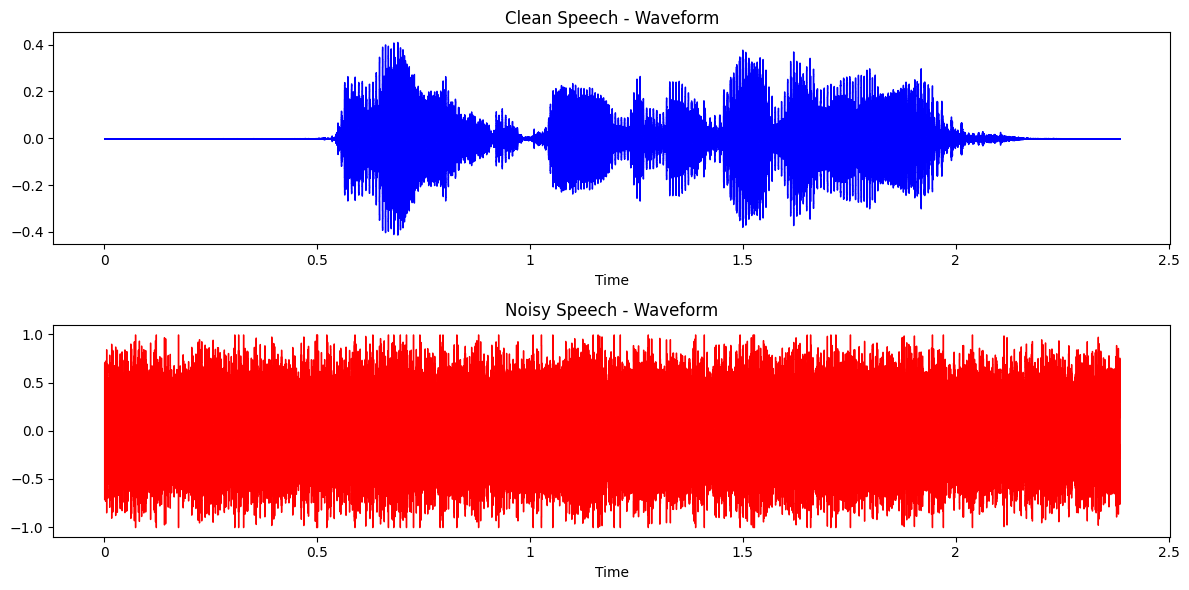

✅ Waveform plot saved!


In [3]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

# Create output folder if it doesn't exist
os.makedirs('data/output', exist_ok=True)

# Load both files
clean, sr = librosa.load('data/raw/clean_speech.wav', sr=16000)
noisy, sr = librosa.load('data/noisy/noisy_speech.wav', sr=16000)

# Plot waveforms
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].set_title('Clean Speech - Waveform')
librosa.display.waveshow(clean, sr=sr, ax=axes[0], color='blue')

axes[1].set_title('Noisy Speech - Waveform')
librosa.display.waveshow(noisy, sr=sr, ax=axes[1], color='red')

plt.tight_layout()
plt.savefig('data/output/waveforms.png')
plt.show()
print('✅ Waveform plot saved!')

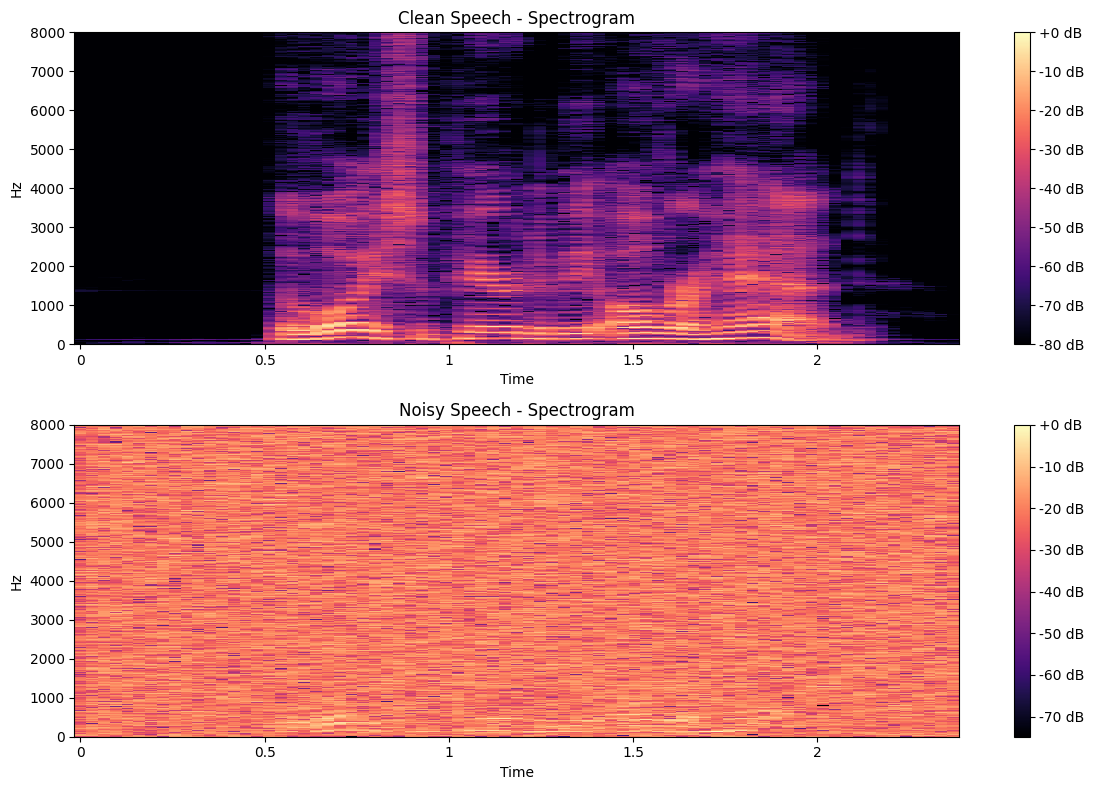

✅ Spectrogram plot saved!


In [4]:
# Plot Spectrograms for deeper analysis
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Clean spectrogram
D_clean = librosa.stft(clean)
librosa.display.specshow(
    librosa.amplitude_to_db(abs(D_clean), ref=np.max),
    sr=sr, x_axis='time', y_axis='hz', ax=axes[0]
)
axes[0].set_title('Clean Speech - Spectrogram')
fig.colorbar(axes[0].collections[0], ax=axes[0], format='%+2.0f dB')

# Noisy spectrogram
D_noisy = librosa.stft(noisy)
librosa.display.specshow(
    librosa.amplitude_to_db(abs(D_noisy), ref=np.max),
    sr=sr, x_axis='time', y_axis='hz', ax=axes[1]
)
axes[1].set_title('Noisy Speech - Spectrogram')
fig.colorbar(axes[1].collections[0], ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.savefig('data/output/spectrograms.png')
plt.show()
print('✅ Spectrogram plot saved!')

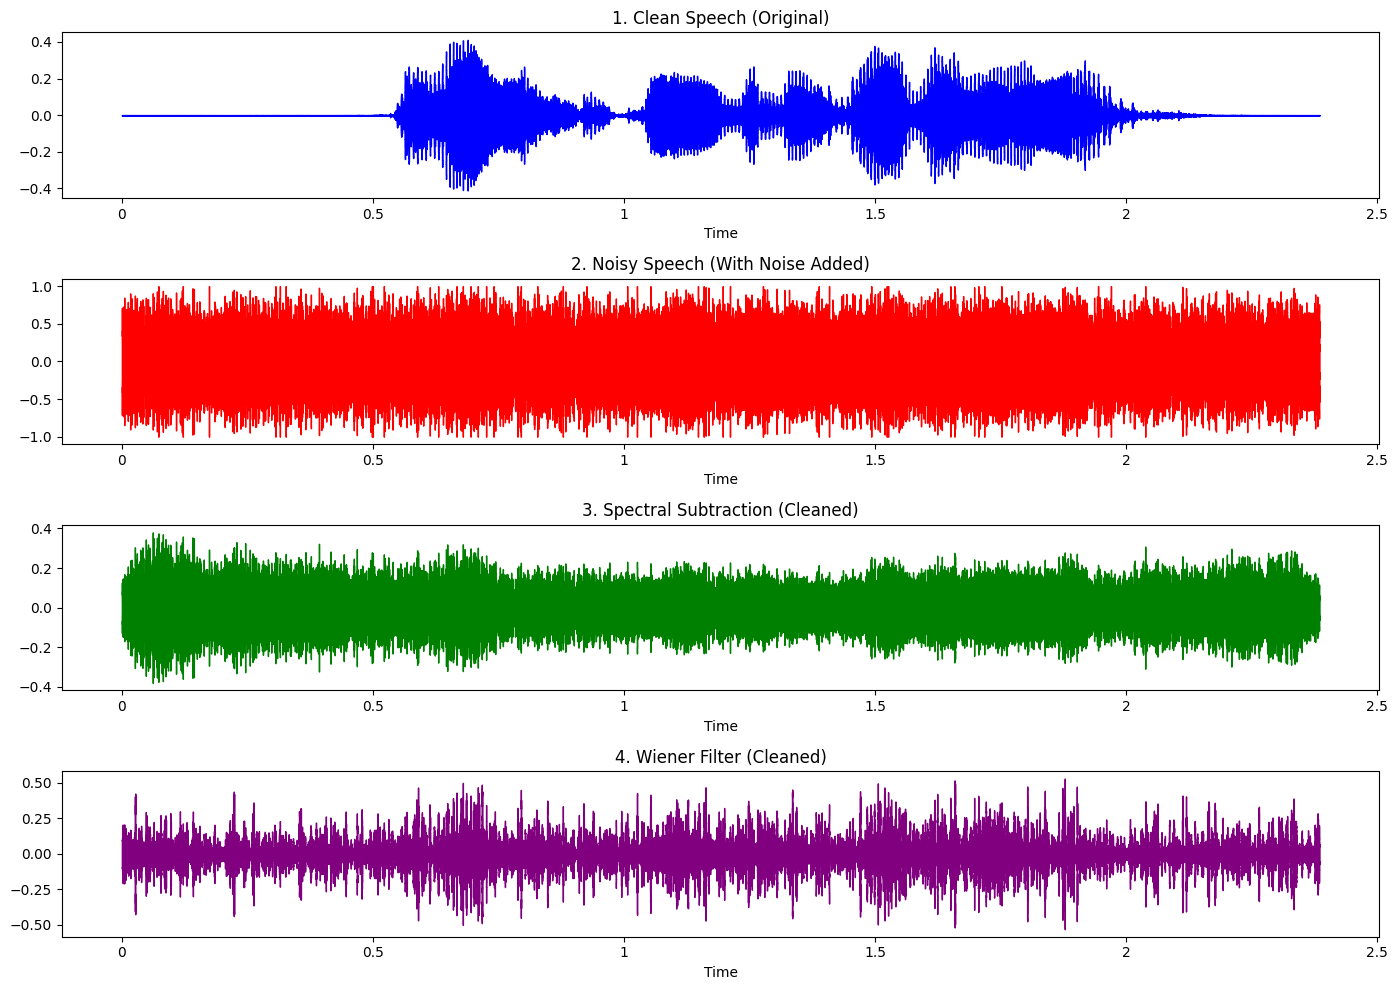

✅ Comparison plot saved!


In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load all audio files
clean, sr    = librosa.load('data/raw/clean_speech.wav', sr=16000)
noisy, sr    = librosa.load('data/noisy/noisy_speech.wav', sr=16000)
spectral, sr = librosa.load('data/output/spectral_cleaned.wav', sr=16000)
wiener, sr   = librosa.load('data/output/wiener_cleaned.wav', sr=16000)

# Plot all 4 waveforms
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].set_title('1. Clean Speech (Original)')
librosa.display.waveshow(clean, sr=sr, ax=axes[0], color='blue')

axes[1].set_title('2. Noisy Speech (With Noise Added)')
librosa.display.waveshow(noisy, sr=sr, ax=axes[1], color='red')

axes[2].set_title('3. Spectral Subtraction (Cleaned)')
librosa.display.waveshow(spectral, sr=sr, ax=axes[2], color='green')

axes[3].set_title('4. Wiener Filter (Cleaned)')
librosa.display.waveshow(wiener, sr=sr, ax=axes[3], color='purple')

plt.tight_layout()
plt.savefig('data/output/comparison_waveforms.png')
plt.show()
print('✅ Comparison plot saved!')

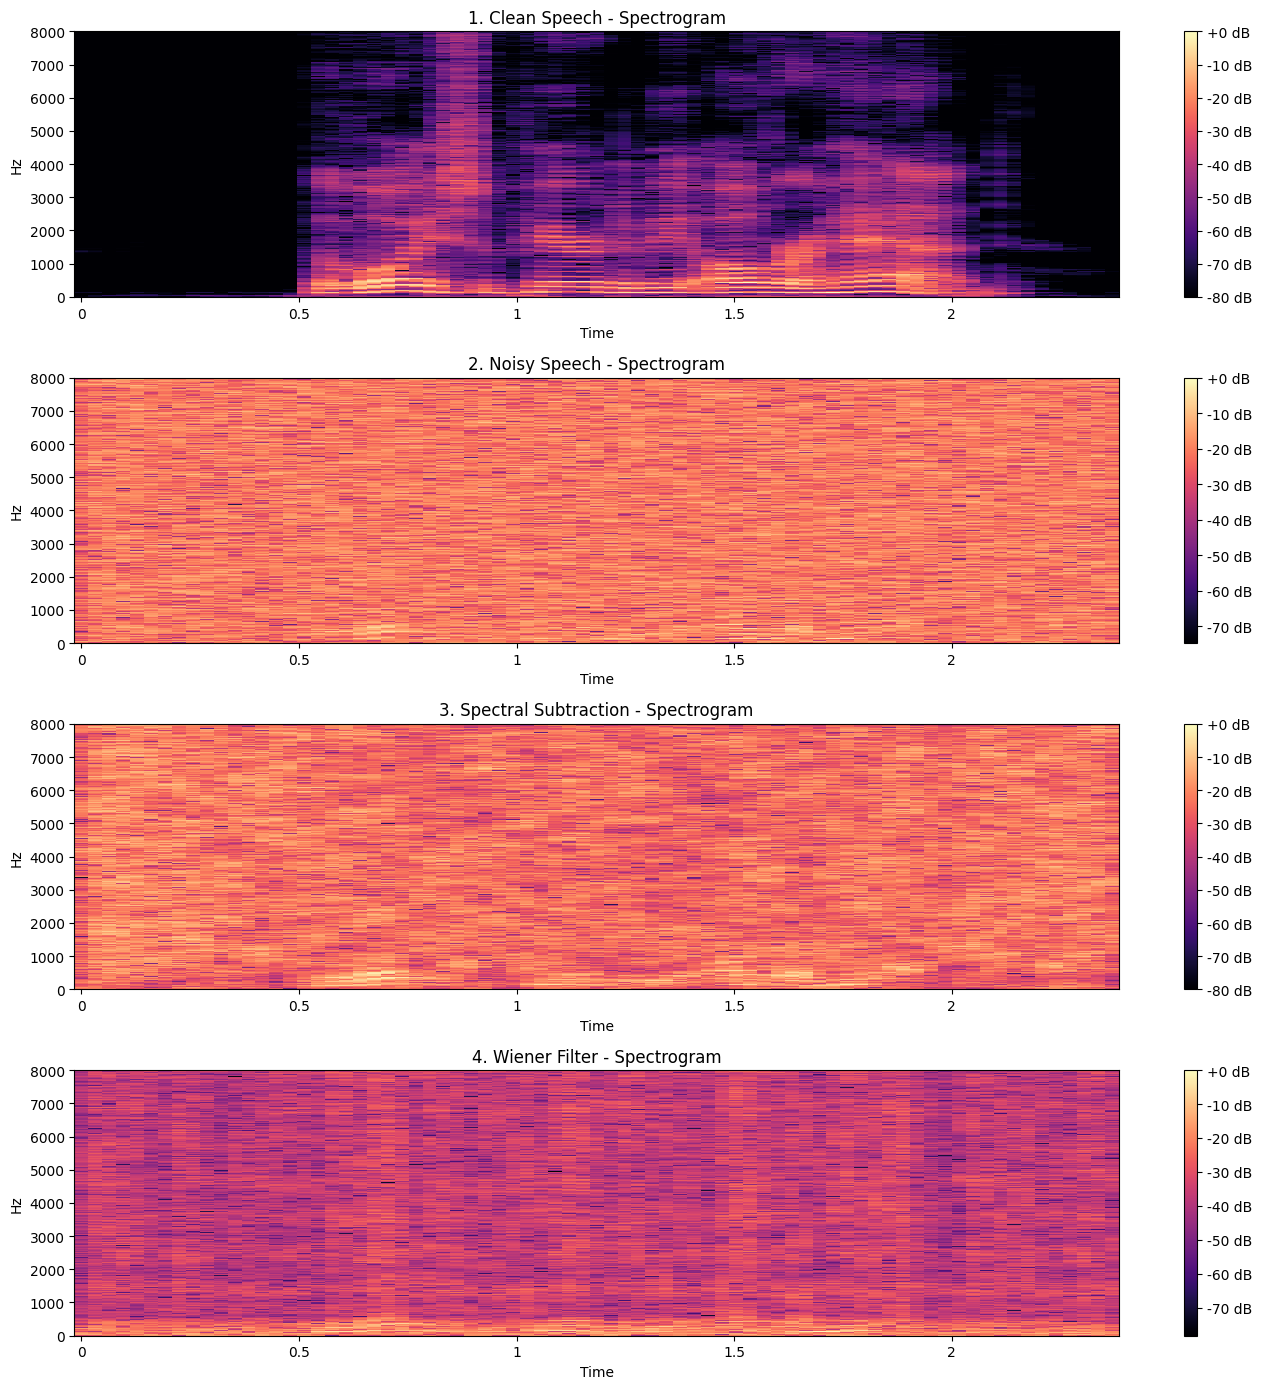

✅ Comparison spectrograms saved!


In [6]:
# Spectrogram comparison of all 4 signals
fig, axes = plt.subplots(4, 1, figsize=(14, 14))

signals = [clean, noisy, spectral, wiener]
titles = [
    '1. Clean Speech - Spectrogram',
    '2. Noisy Speech - Spectrogram',
    '3. Spectral Subtraction - Spectrogram',
    '4. Wiener Filter - Spectrogram'
]

for i, (signal, title) in enumerate(zip(signals, titles)):
    D = librosa.stft(signal)
    img = librosa.display.specshow(
        librosa.amplitude_to_db(abs(D), ref=np.max),
        sr=sr, x_axis='time', y_axis='hz', ax=axes[i]
    )
    axes[i].set_title(title)
    fig.colorbar(img, ax=axes[i], format='%+2.0f dB')

plt.tight_layout()
plt.savefig('data/output/comparison_spectrograms.png')
plt.show()
print('✅ Comparison spectrograms saved!')